In [1]:
import re
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd 

In [2]:
def _calculate_rate_details_for_file(h5_path, label, run_type, plot_timestamps=True):
    filename = os.path.basename(h5_path)
    stats = {
        'measured_rate': 0.0,
        'lost_rate': 0.0,
        'corrected_rate': 0.0,
        'events_registered': 0,
        'events_lost': 0,
        'time_sec': 0.0,
        'is_cleaned': False,
        'events_dropped': 0
    }

    try:
        df_raw = pd.read_hdf(h5_path, 'data')
        
        if df_raw.empty or 'timestamp' not in df_raw.columns or 'lostBuffer' not in df_raw.columns:
            print(f"      [!] Error: Missing data or required columns in {filename}")
            return stats

        # --- 1. Detect and Clean Gaps ---
        df_sorted = df_raw.sort_values(by='timestamp').copy()
        threshold_ms = 10.0 * 1000 # 10 seconds
        
        deltas = df_sorted['timestamp'].diff()
        group_ids = (deltas > threshold_ms).cumsum()
        df_sorted['group_id'] = group_ids 
        
        group_counts = df_sorted['group_id'].value_counts()
        winner_group_id = group_counts.idxmax()
        data_df = df_sorted[df_sorted['group_id'] == winner_group_id].copy()

        stats['is_cleaned'] = len(group_counts) > 1
        stats['events_dropped'] = len(df_sorted) - len(data_df)

        if stats['is_cleaned']:
            print(f"      [!] Gap Cleaning Triggered: Removed {len(group_counts)-1} gap cluster(s). Dropped {stats['events_dropped']} events.")

        # --- 2. Plot Timestamp Distribution ---
        if plot_timestamps and not df_sorted.empty:
            t_start = df_sorted['timestamp'].iloc[0]
            all_times_min = (df_sorted['timestamp'] - t_start) / 60000.0 
            
            mask_kept = df_sorted['group_id'] == winner_group_id
            mask_discarded = ~mask_kept
            
            times_kept = all_times_min[mask_kept]
            times_discarded = all_times_min[mask_discarded]
            
            plt.style.use('ggplot')
            plt.figure(figsize=(10, 5))
            bins = np.linspace(all_times_min.min(), all_times_min.max(), 100)
            
            if len(times_discarded) > 0:
                plt.hist(times_discarded, bins=bins, color='red', alpha=1.0, 
                         label=f'Discarded ({stats["events_dropped"]} evts)', log=True)
            
            plt.hist(times_kept, bins=bins, color='blue', alpha=0.6, 
                     label=f'Kept Data ({len(times_kept)} evts)', log=True)
            
            plt.title(f"Time Distribution: {label}\n(File: {filename})")
            plt.xlabel("Time since file start (min)")
            plt.ylabel("Counts (Log Scale)")
            plt.legend()
            plt.grid(True, which="both", linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

        if data_df.empty:
            return stats

        # --- 3. Calculate Detailed Rates ---
        first_timestamp = data_df['timestamp'].iloc[0]
        last_timestamp = data_df['timestamp'].iloc[-1]
        time_difference = (last_timestamp - first_timestamp) * 0.001

        if time_difference > 0:
            events_registered = len(data_df)
            events_lost = data_df['lostBuffer'].sum()
            total_events_estimated = events_registered + events_lost
            
            stats['time_sec'] = time_difference
            stats['events_registered'] = events_registered
            stats['events_lost'] = int(events_lost)
            stats['measured_rate'] = events_registered / time_difference
            stats['lost_rate'] = events_lost / time_difference
            stats['corrected_rate'] = total_events_estimated / time_difference
            
        return stats
            
    except Exception as e:
        print(f"      [!] Could not calculate rate for {filename}: {e}")
        return stats


def _plot_charge_histogram_for_file(h5_path, label, run_type):
    filename = os.path.basename(h5_path)
    try:
        with h5py.File(h5_path, "r") as f:
            if 'charges' not in f:
                print(f"  [!] Warning: 'charges' dataset not found in {filename}.")
                return

            charges = f["charges"][:]
            
            if charges.size == 0 or charges.shape[1] < 12:
                print(f"  [!] Warning: No data or insufficient columns in {filename}.")
                return
                
            charge_ch0 = charges[:, 0]
            charge_ch10 = charges[:, 10]
            charge_ch11 = charges[:, 11]

            plt.style.use('ggplot')
            plt.figure(figsize=(12, 7))
            
            bins = np.linspace(150, 1200, 100)

            plt.hist(charge_ch0, bins=bins, alpha=0.6, histtype='step', linewidth=2, label='Channel 0 (Control/Noise)')
            plt.hist(charge_ch10, bins=bins, alpha=0.6, histtype='step', linewidth=2, label='Channel 10 (Active)')
            plt.hist(charge_ch11, bins=bins, alpha=0.6, histtype='step', linewidth=2, label='Channel 11 (Active)')

            plt.title(f'Charge Distribution: {label}\n(File: {filename})')
            plt.xlabel('Charge (ADC Counts)')
            plt.ylabel('Frequency (Counts)')
            plt.yscale('log')
            plt.legend()
            plt.grid(True, which='both', linestyle='--')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"  [!] An error occurred while plotting charge histogram for {filename}: {e}")


def analyze_custom_runs(directory, selected_runs=None):
    """
    Analyzes an arbitrary number of files without assigning specific physical positions.
    
    Args:
        directory (str): Path to the folder with the data.
        selected_runs (list, optional): A list of integer run numbers to analyze. 
                                        If None, analyzes ALL valid files in the folder.
                                        Example: selected_runs=[405, 406, 408, 410]
    """
    directory = os.path.normpath(directory)
    if not os.path.isdir(directory):
        print(f"Error: Directory not found: {directory}")
        return

    print(f"\n{'='*60}")
    print(f"--- Custom Run Analysis Mode ---")
    print(f"{'='*60}")

    # --- 1. Find and Filter Files ---
    all_files = os.listdir(directory)
    run_files_info = []
    
    for filename in all_files:
        if filename.startswith('muons_run_') and filename.endswith('.h5'):
            match = re.search(r'muons_run_(\d+)\.h5', filename)
            if match:
                run_number = int(match.group(1))
                # If selected_runs is provided, filter out unwanted runs
                if selected_runs is None or run_number in selected_runs:
                    run_files_info.append({'filename': filename, 'run_number': run_number})

    # Sort files by run number
    run_files_info.sort(key=lambda x: x['run_number'])

    if not run_files_info:
        print("No valid runs found matching your criteria.")
        return

    print(f"Found {len(run_files_info)} files to analyze.")
    print("-" * 60)
    
    run_labels = []
    corrected_rates = []
    cleaned_flags = []
    
    # --- 2. Calculate Detailed Rates & Plot Timestamps ---
    for file_info in run_files_info:
        run_num = file_info['run_number']
        filename = file_info['filename']
        fpath = os.path.join(directory, filename)
        
        label = f"Run {run_num}"
        run_labels.append(label)
        
        print(f"[{label}] Using file: {filename}")
        
        stats = _calculate_rate_details_for_file(fpath, label, "Custom Check", plot_timestamps=True)
        
        corrected_rates.append(stats['corrected_rate'])
        cleaned_flags.append(stats['is_cleaned'])
        
        print(f"      Analyzed Time : {stats['time_sec']:.2f} seconds")
        print(f"      Events Saved  : {stats['events_registered']:,}")
        print(f"      Events Lost   : {stats['events_lost']:,} (from lostBuffer)")
        print(f"      Measured Rate : {stats['measured_rate']:,.2f} Hz")
        print(f"      Lost Rate     : {stats['lost_rate']:,.2f} Hz (+ added by efficiency)")
        print(f"      FINAL RATE    : {stats['corrected_rate']:,.2f} Hz\n")

    # --- 3. Plot Final Corrected Rates Bar Chart ---
    plt.style.use('ggplot')
    plt.figure(figsize=(max(10, len(run_labels)*1.2), 6)) # Dynamically resize if many files
    
    bars = plt.bar(run_labels, corrected_rates, color='royalblue')
    
    plt.ylabel('Corrected Rate (Hz)')
    plt.title('Corrected Event Rates for Custom Selected Runs')
    
    for idx, bar in enumerate(bars):
        yval = bar.get_height()
        label_text = f'{yval:,.2f} Hz'
        if cleaned_flags[idx]:
            label_text += '\n(Cleaned)'
            
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.02), label_text, va='bottom', ha='center', fontweight='bold', fontsize=9)

    max_rate = max(corrected_rates) if corrected_rates else 100
    plt.ylim(0, max_rate * 1.15) 
    plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
    plt.tight_layout()
    plt.show()

    # --- 4. Plot Charge Distributions ---
    print("-" * 60)
    print("Generating charge distribution plots...")
    for file_info in run_files_info:
        run_num = file_info['run_number']
        filename = file_info['filename']
        fpath = os.path.join(directory, filename)
        label = f"Run {run_num}"
        
        _plot_charge_histogram_for_file(fpath, label, "Custom Check")
        
    print("\n--- Custom Analysis Complete ---\n")


--- Custom Run Analysis Mode ---
Found 7 files to analyze.
------------------------------------------------------------
[Run 447] Using file: muons_run_447.h5


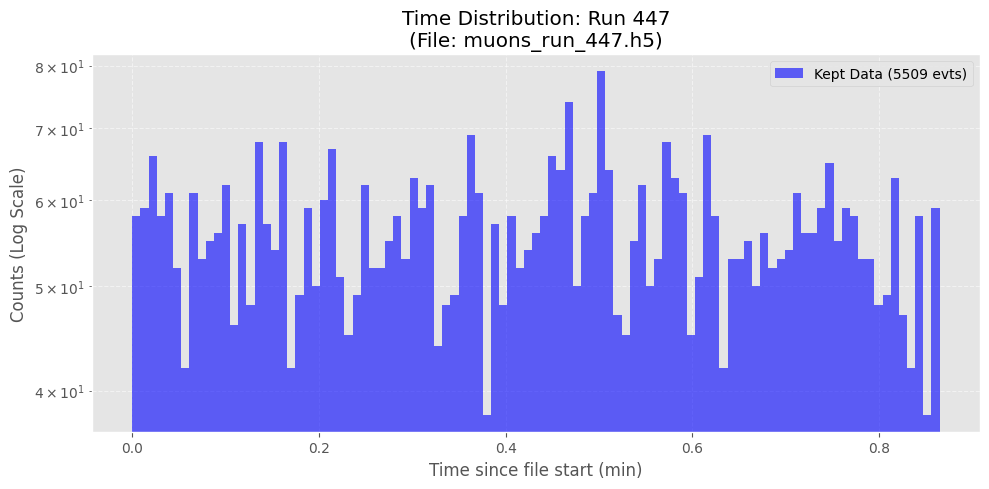

      Analyzed Time : 51.90 seconds
      Events Saved  : 5,509
      Events Lost   : 95 (from lostBuffer)
      Measured Rate : 106.15 Hz
      Lost Rate     : 1.83 Hz (+ added by efficiency)
      FINAL RATE    : 107.98 Hz

[Run 448] Using file: muons_run_448.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 3 events.


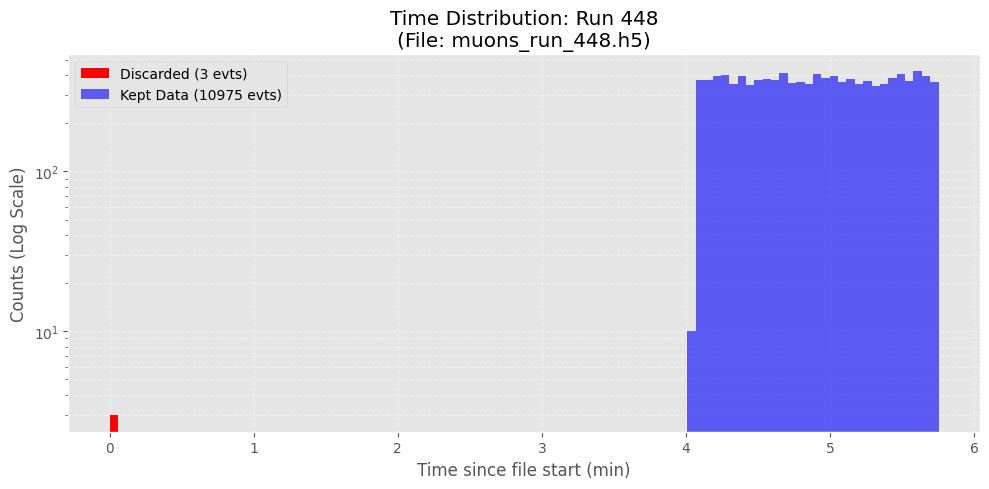

      Analyzed Time : 101.24 seconds
      Events Saved  : 10,975
      Events Lost   : 197 (from lostBuffer)
      Measured Rate : 108.40 Hz
      Lost Rate     : 1.95 Hz (+ added by efficiency)
      FINAL RATE    : 110.35 Hz

[Run 449] Using file: muons_run_449.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 9 events.


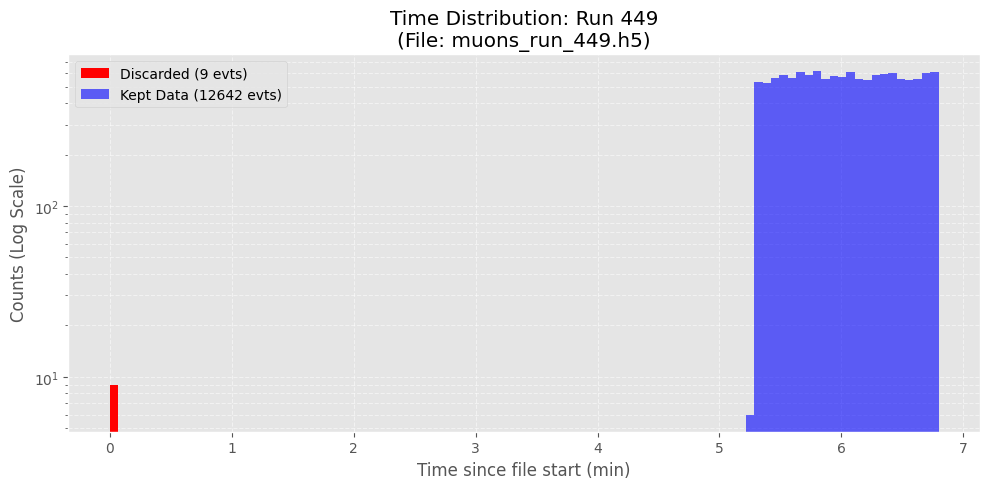

      Analyzed Time : 90.63 seconds
      Events Saved  : 12,642
      Events Lost   : 184 (from lostBuffer)
      Measured Rate : 139.49 Hz
      Lost Rate     : 2.03 Hz (+ added by efficiency)
      FINAL RATE    : 141.52 Hz

[Run 450] Using file: muons_run_450.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 7 events.


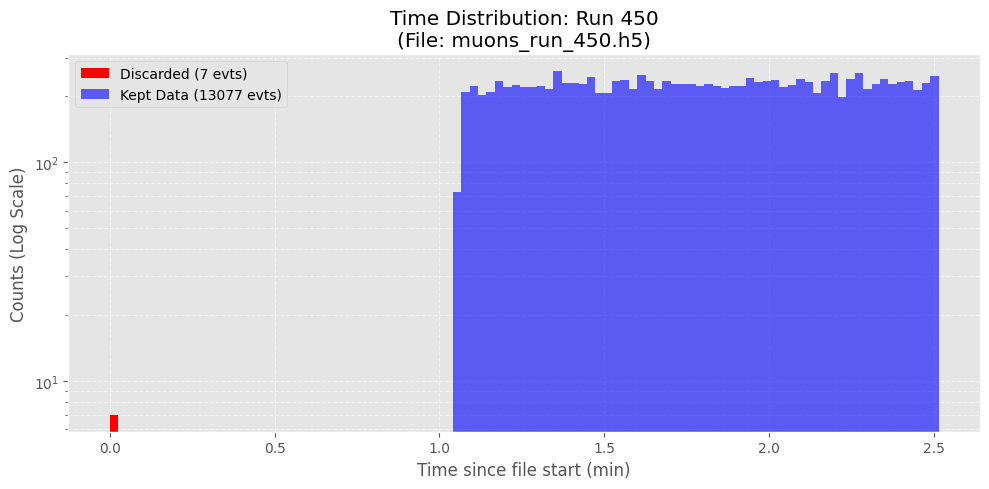

      Analyzed Time : 87.36 seconds
      Events Saved  : 13,077
      Events Lost   : 219 (from lostBuffer)
      Measured Rate : 149.70 Hz
      Lost Rate     : 2.51 Hz (+ added by efficiency)
      FINAL RATE    : 152.20 Hz

[Run 451] Using file: muons_run_451.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 5 events.


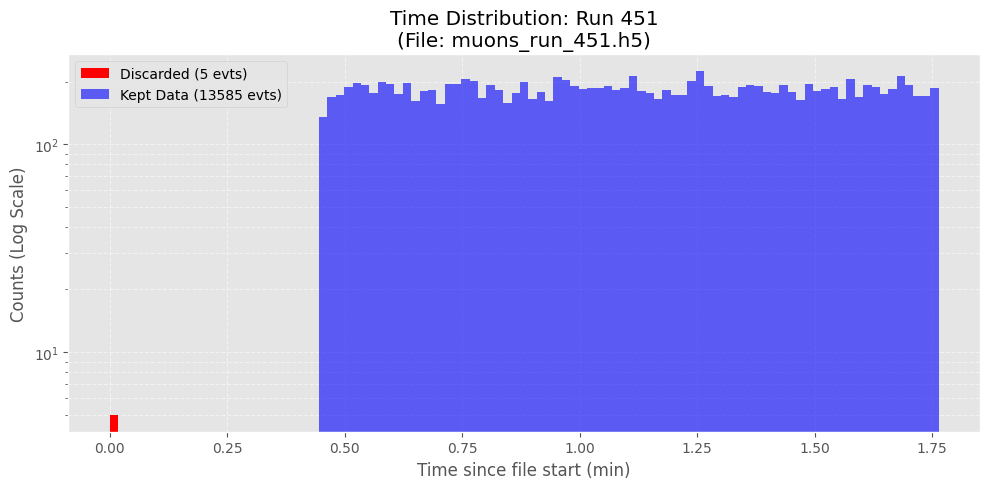

      Analyzed Time : 78.76 seconds
      Events Saved  : 13,585
      Events Lost   : 182 (from lostBuffer)
      Measured Rate : 172.49 Hz
      Lost Rate     : 2.31 Hz (+ added by efficiency)
      FINAL RATE    : 174.80 Hz

[Run 452] Using file: muons_run_452.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 8 events.


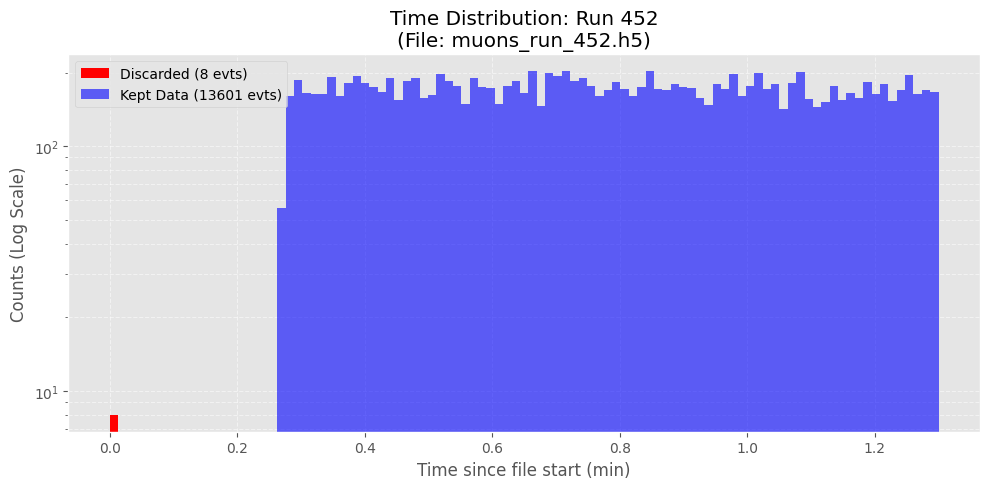

      Analyzed Time : 61.76 seconds
      Events Saved  : 13,601
      Events Lost   : 161 (from lostBuffer)
      Measured Rate : 220.21 Hz
      Lost Rate     : 2.61 Hz (+ added by efficiency)
      FINAL RATE    : 222.82 Hz

[Run 453] Using file: muons_run_453.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 9 events.


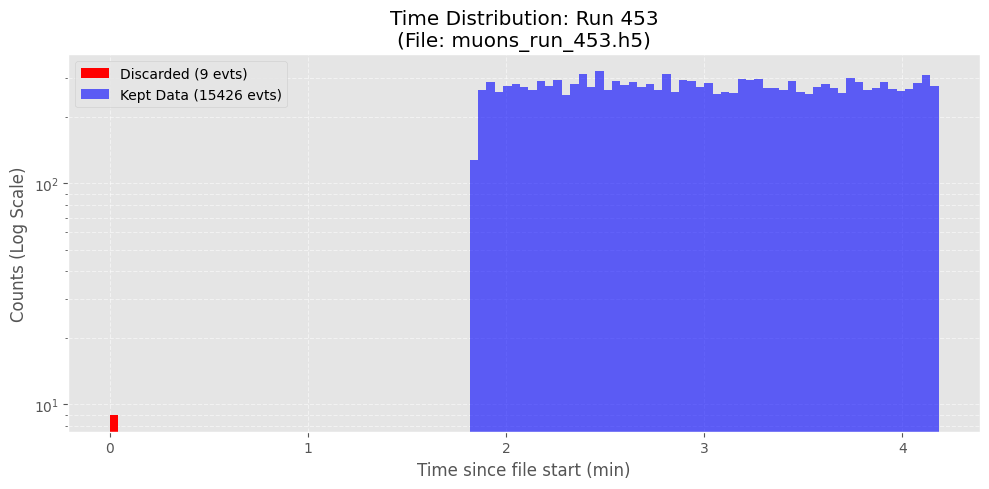

      Analyzed Time : 140.60 seconds
      Events Saved  : 15,426
      Events Lost   : 271 (from lostBuffer)
      Measured Rate : 109.72 Hz
      Lost Rate     : 1.93 Hz (+ added by efficiency)
      FINAL RATE    : 111.65 Hz



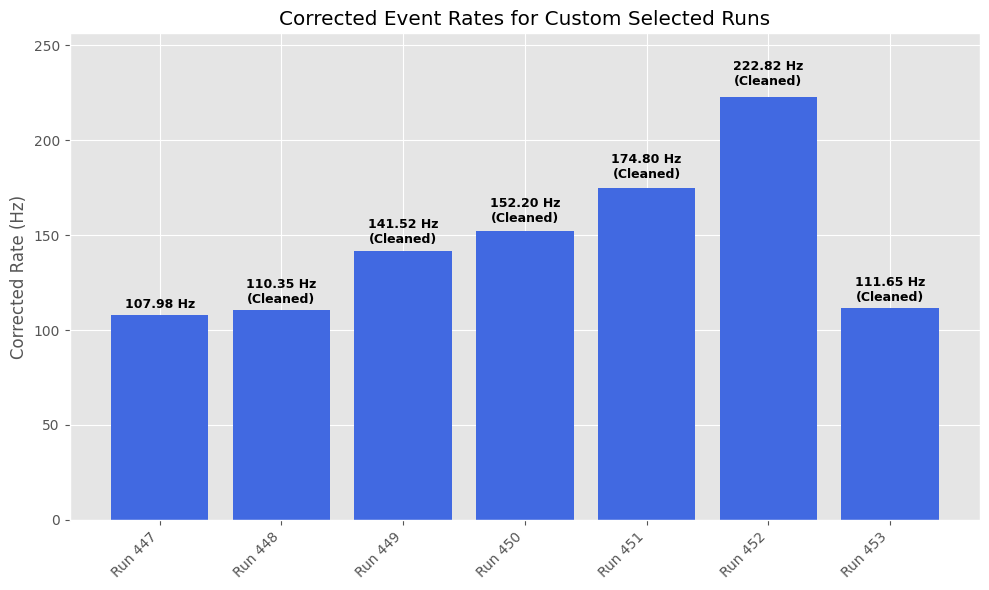

------------------------------------------------------------
Generating charge distribution plots...


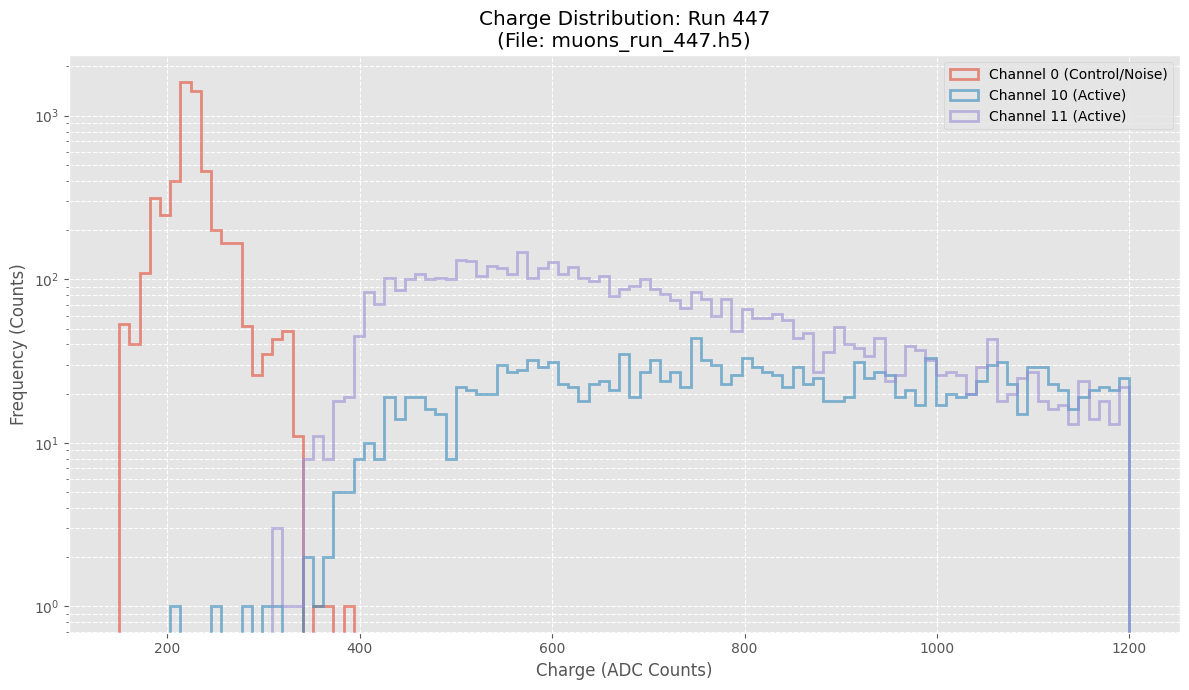

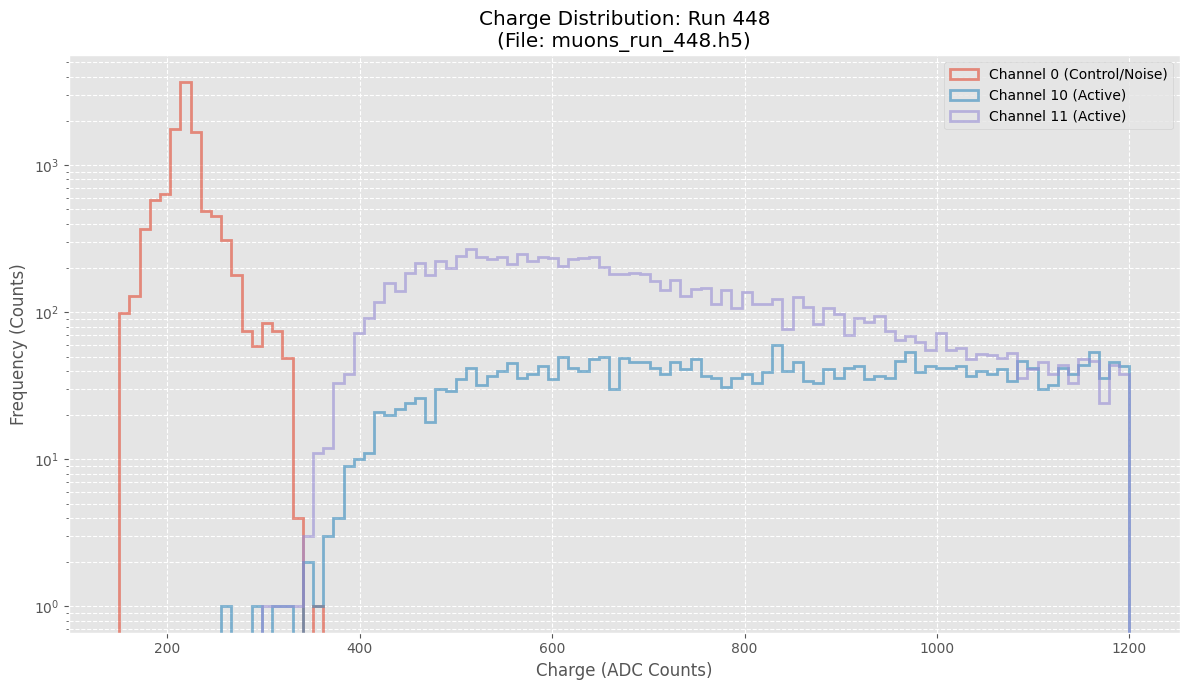

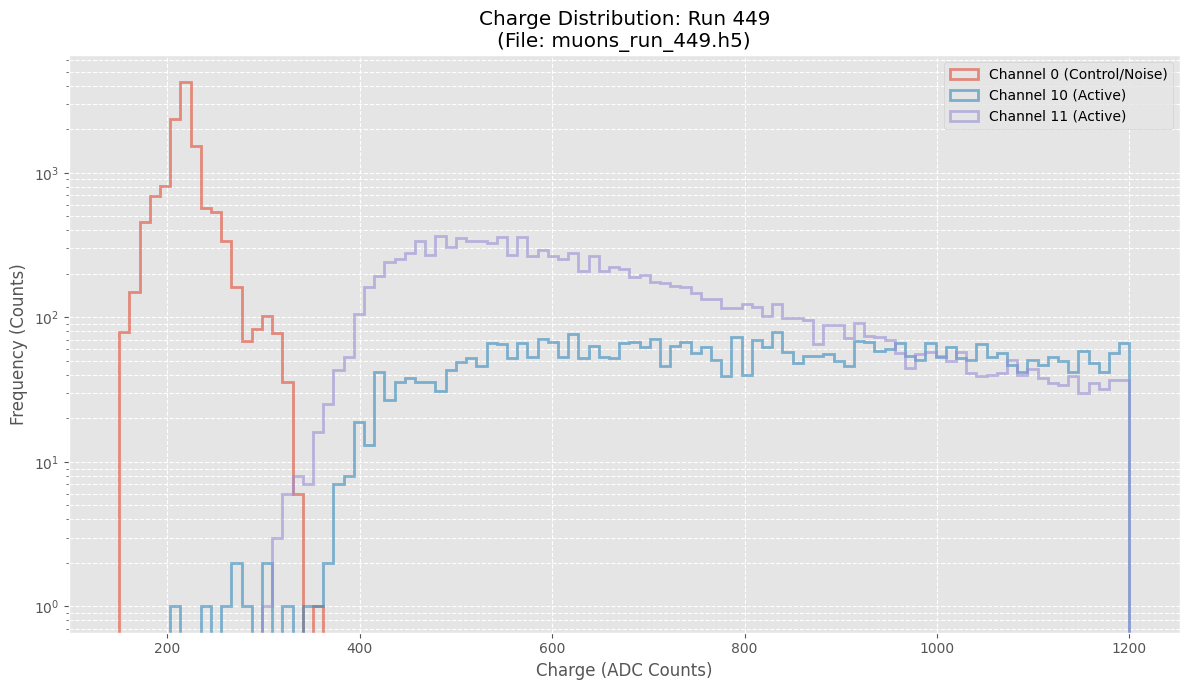

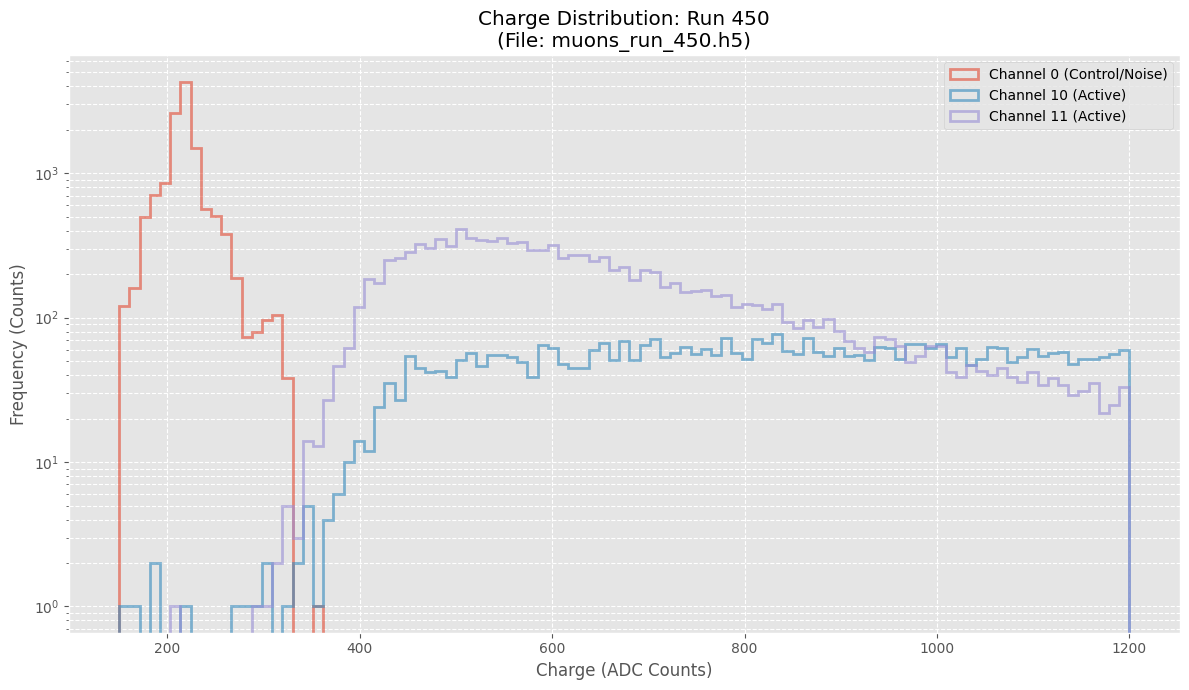

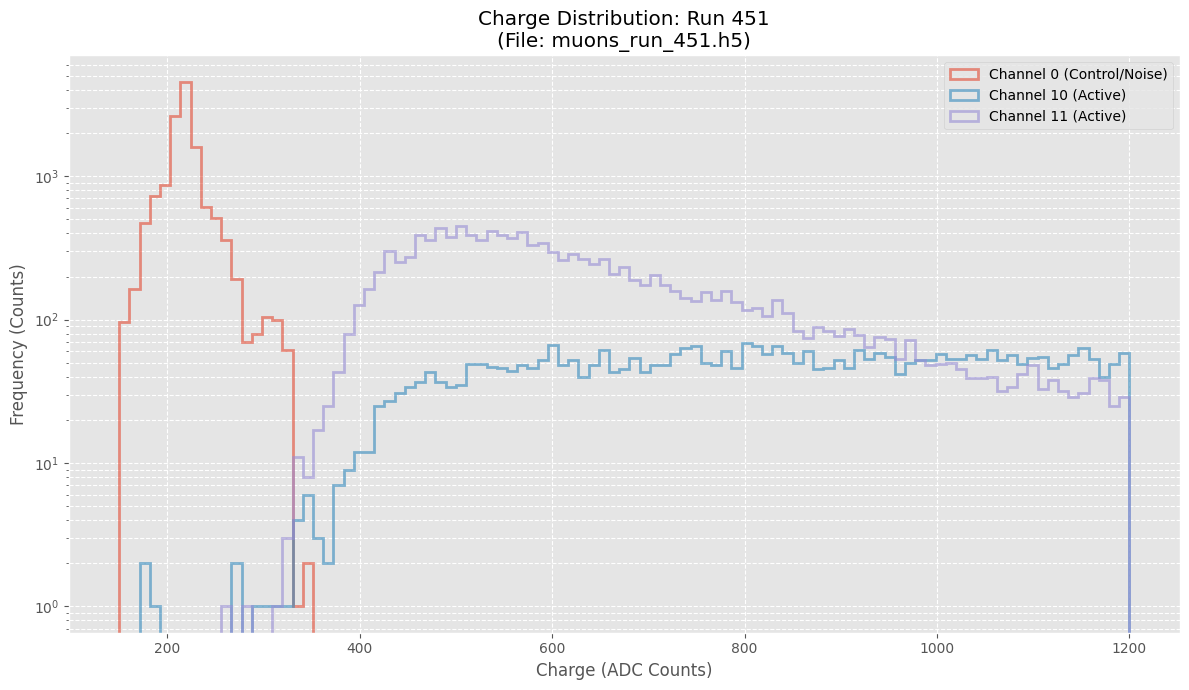

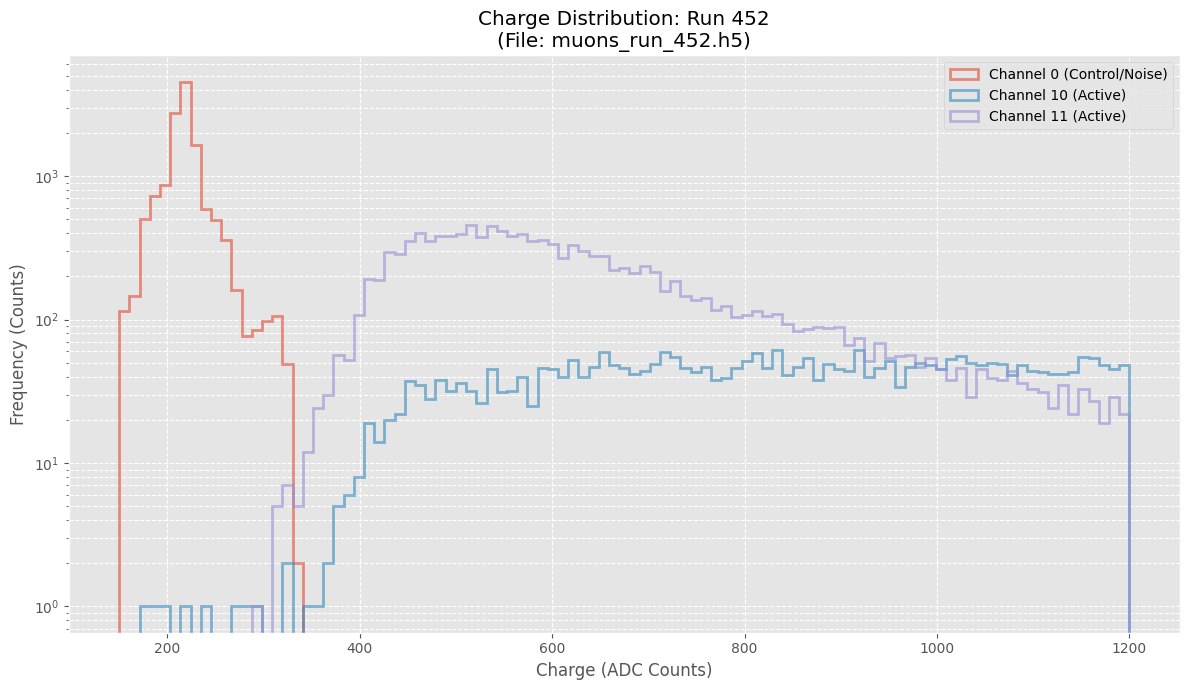

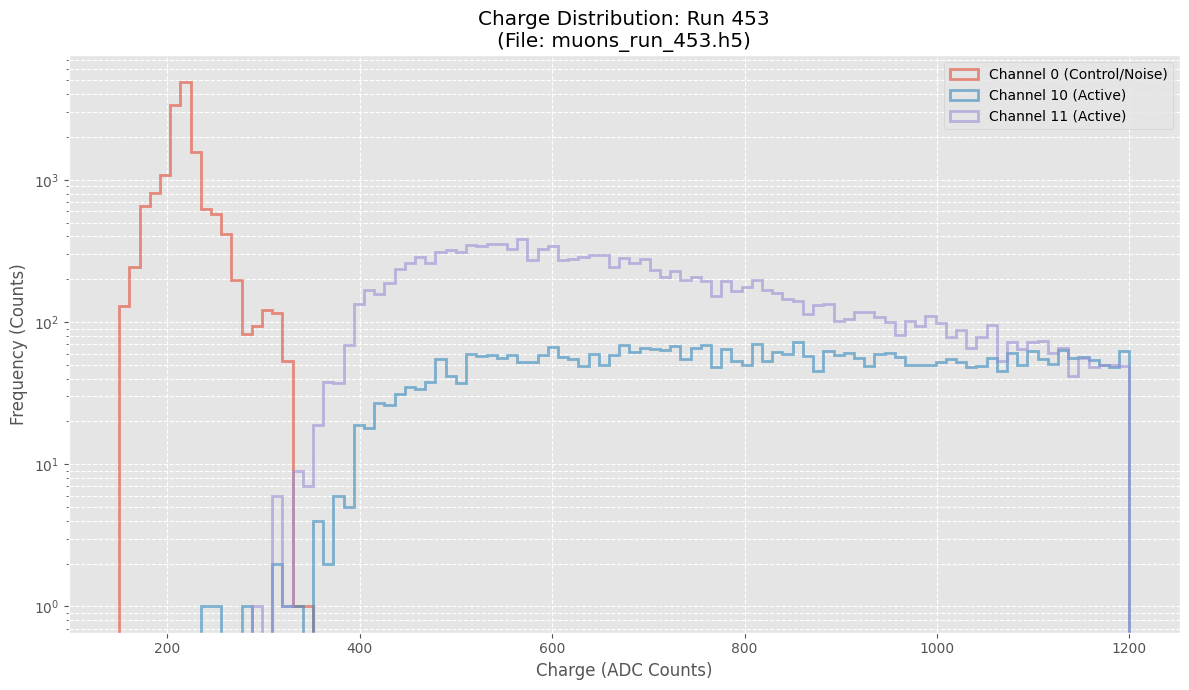


--- Custom Analysis Complete ---



In [3]:
analyze_custom_runs("/lhome/ific/v/villamil/muonveto/long_bars/blind_test")


--- Custom Run Analysis Mode ---
Found 5 files to analyze.
------------------------------------------------------------
[Run 454] Using file: muons_run_454.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 1 events.


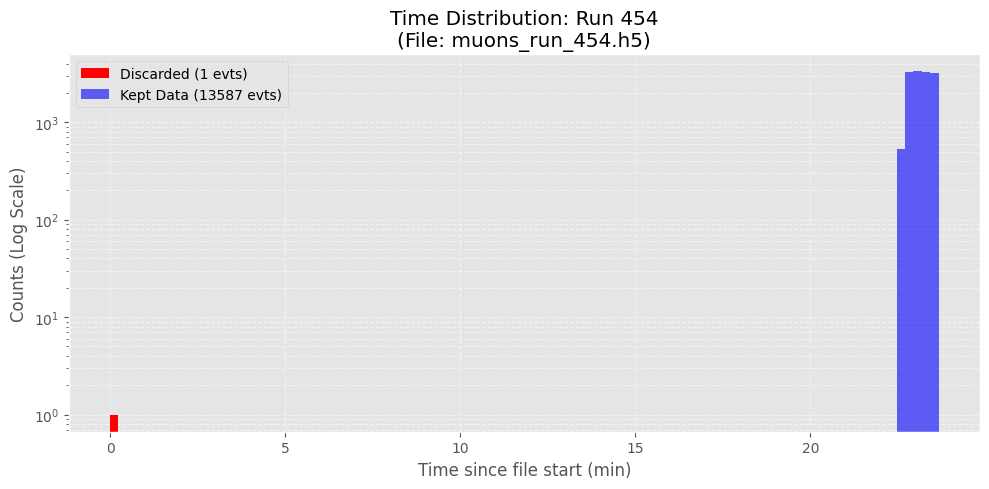

      Analyzed Time : 59.57 seconds
      Events Saved  : 13,587
      Events Lost   : 349 (from lostBuffer)
      Measured Rate : 228.07 Hz
      Lost Rate     : 5.86 Hz (+ added by efficiency)
      FINAL RATE    : 233.93 Hz

[Run 455] Using file: muons_run_455.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 2 events.


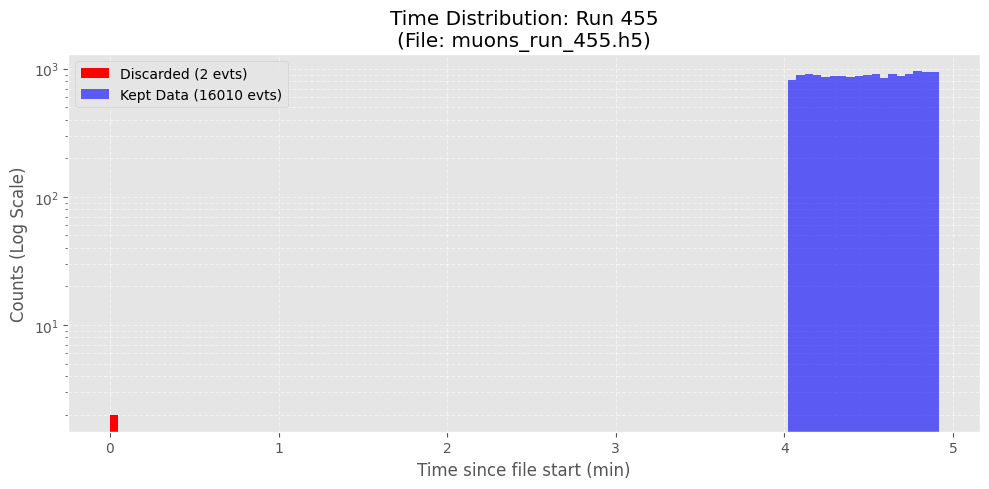

      Analyzed Time : 53.38 seconds
      Events Saved  : 16,010
      Events Lost   : 428 (from lostBuffer)
      Measured Rate : 299.90 Hz
      Lost Rate     : 8.02 Hz (+ added by efficiency)
      FINAL RATE    : 307.92 Hz

[Run 456] Using file: muons_run_456.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 11 events.


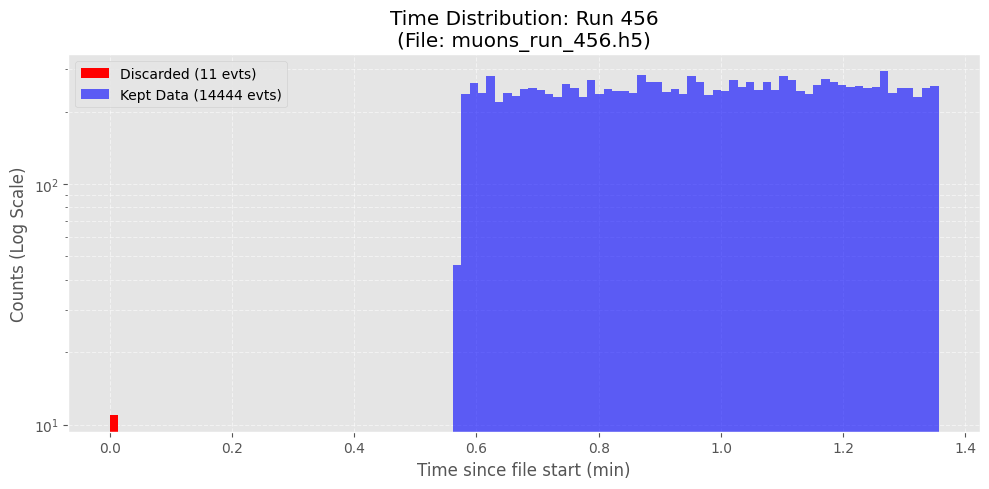

      Analyzed Time : 46.96 seconds
      Events Saved  : 14,444
      Events Lost   : 441 (from lostBuffer)
      Measured Rate : 307.59 Hz
      Lost Rate     : 9.39 Hz (+ added by efficiency)
      FINAL RATE    : 316.98 Hz

[Run 457] Using file: muons_run_457.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 7 events.


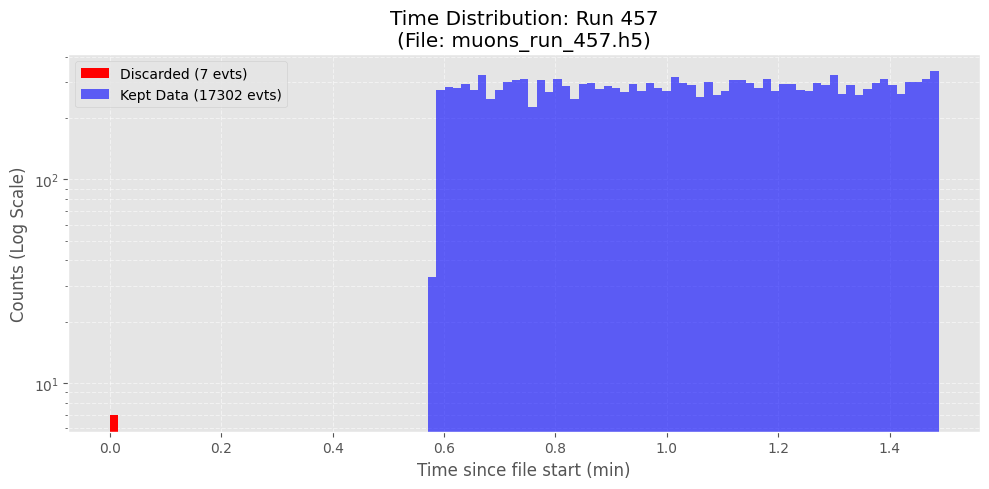

      Analyzed Time : 54.16 seconds
      Events Saved  : 17,302
      Events Lost   : 520 (from lostBuffer)
      Measured Rate : 319.45 Hz
      Lost Rate     : 9.60 Hz (+ added by efficiency)
      FINAL RATE    : 329.05 Hz

[Run 458] Using file: muons_run_458.h5


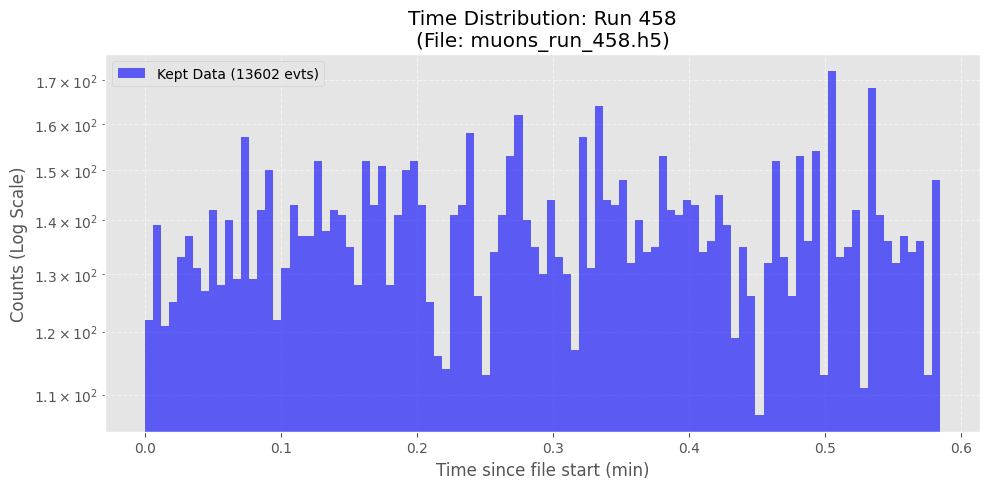

      Analyzed Time : 35.08 seconds
      Events Saved  : 13,602
      Events Lost   : 357 (from lostBuffer)
      Measured Rate : 387.72 Hz
      Lost Rate     : 10.18 Hz (+ added by efficiency)
      FINAL RATE    : 397.90 Hz



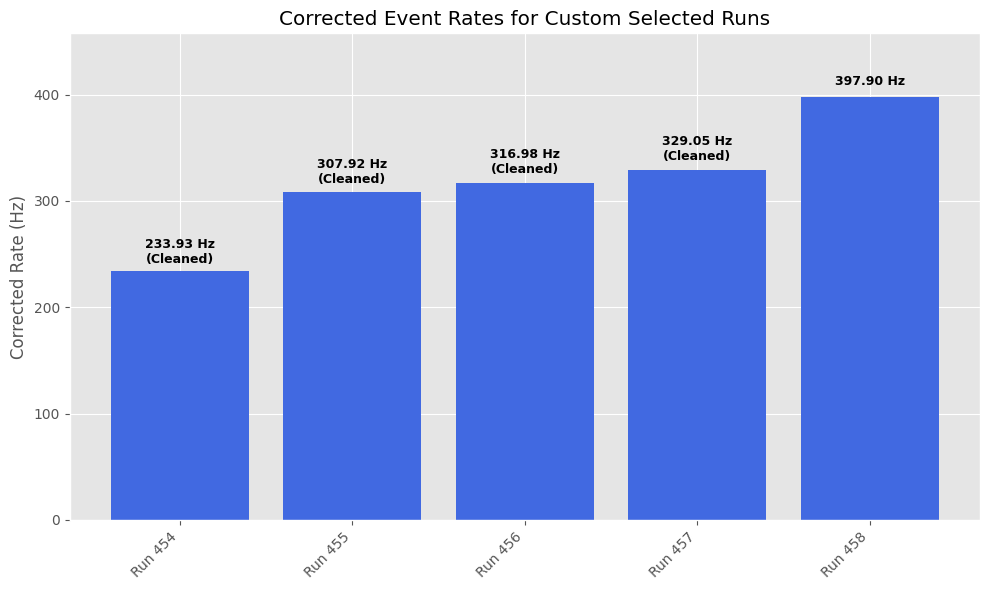

------------------------------------------------------------
Generating charge distribution plots...


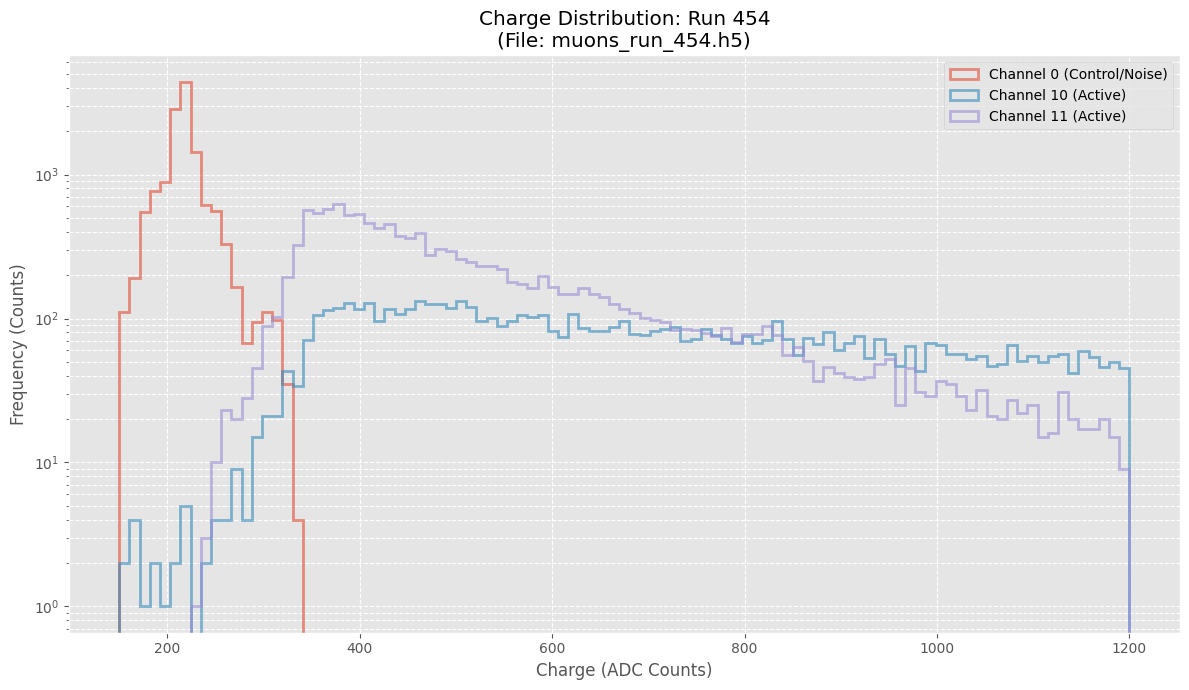

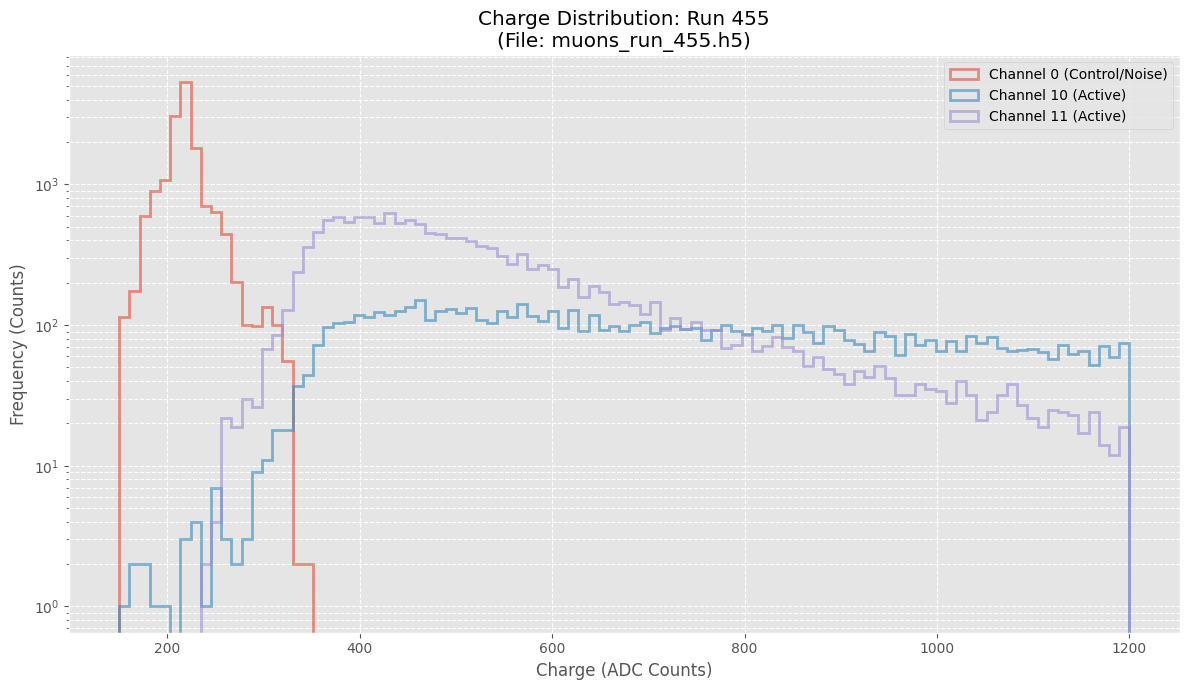

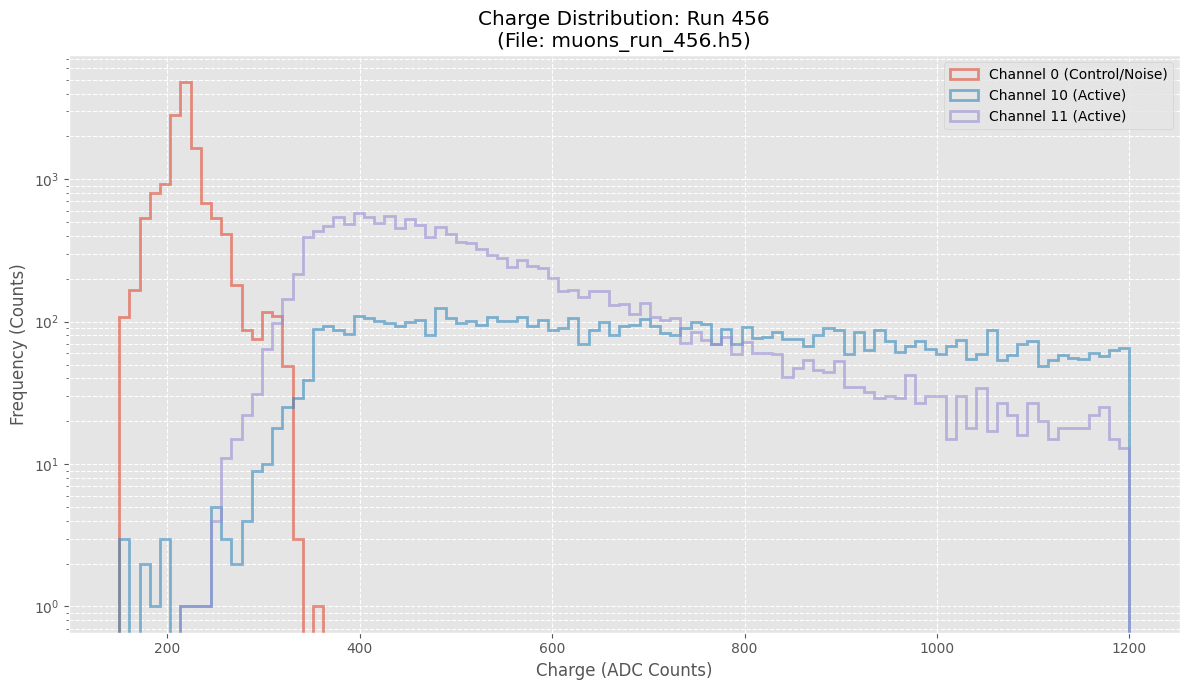

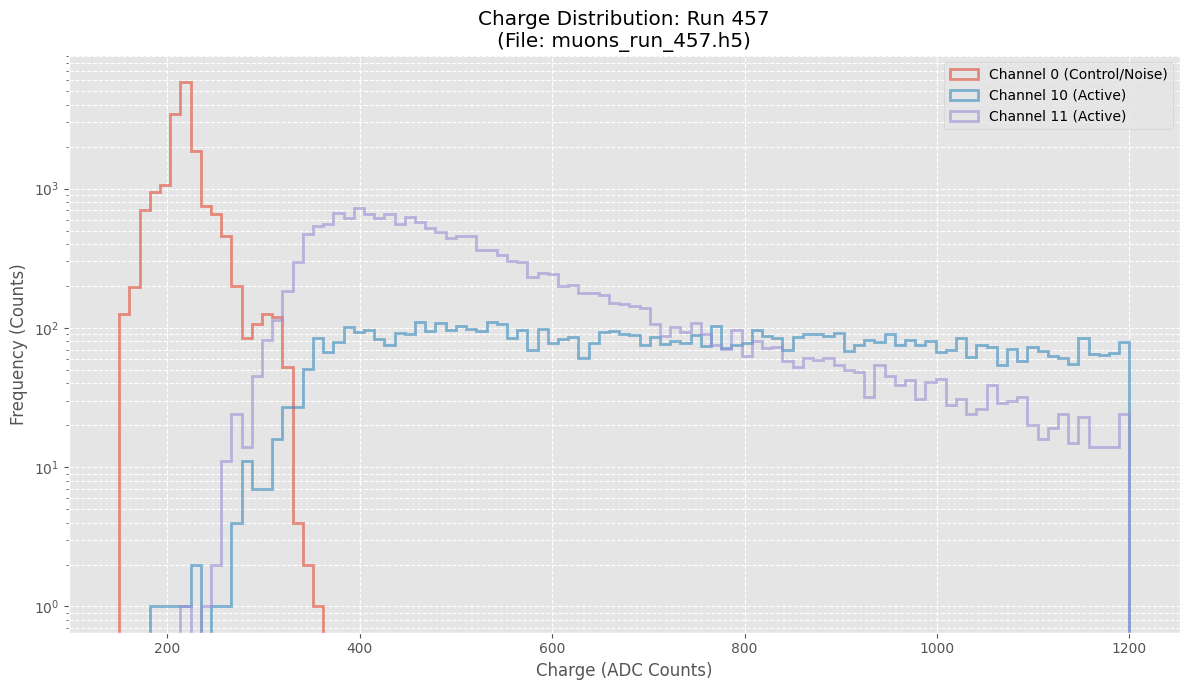

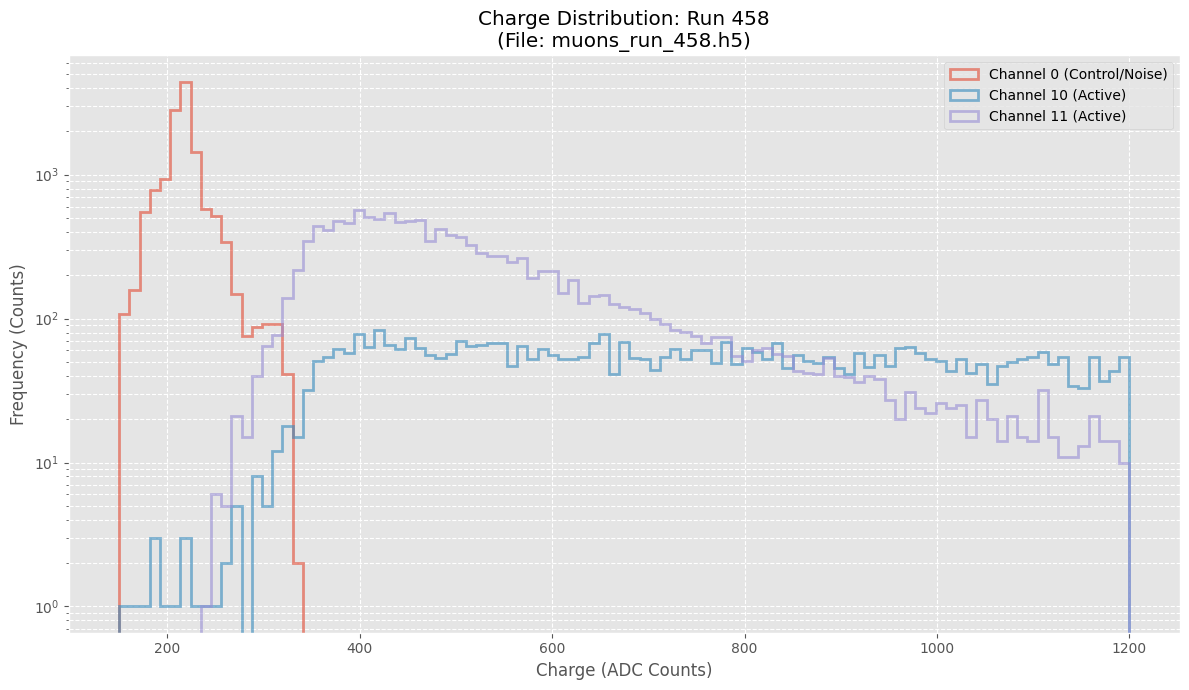


--- Custom Analysis Complete ---



In [5]:
analyze_custom_runs("/lhome/ific/v/villamil/muonveto/long_bars/blind_test_2")